In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch

import cv2

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset, GameDataset

import importlib
import ChessLens
importlib.reload(ChessLens);

In [10]:
ds = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
# ds = GameDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
img, y = ds[15]
# img, y = ds[278]
# img, y = ds[57]

# img = ChessLens.ChessLensImage(os.path.join(DataPath, 'data_manual/1741715439429.jpg'))
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Games/Training_Session/game_50.jpg")
img = ChessLens.ChessLensImage(img, "cnn")
y["image_path"]

'/mnt/D/University/Thesis_Dataset/Dataset/Images/image_16.jpg'

In [11]:
quad, conf = img.detect_board()
# img.recognize_clock()
img.recognize_pieces()
img.save_fen_image()

'1pp2R1R/8/qp1n1BP1/kbpb3K/3N1Q1Q/4PN2/1pq3P1/rp4PR'

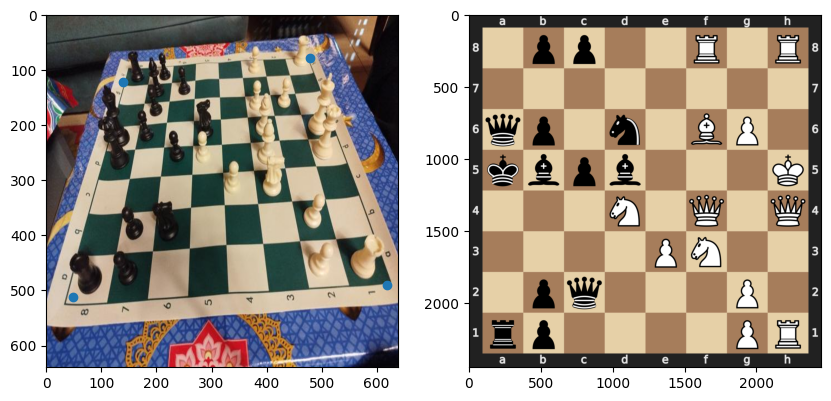

In [12]:
plt.figure(figsize=(10, 10))

plt.subplot(1,2,1)
plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
plt.subplot(1,2,2)
plt.imshow(plt.imread("out_fen.png"));
img.fen

array([[      1.169,     0.27576,      -197.3],
       [    0.20343,      1.5325,     -215.45],
       [ 0.00065657,   0.0024025,           1]])

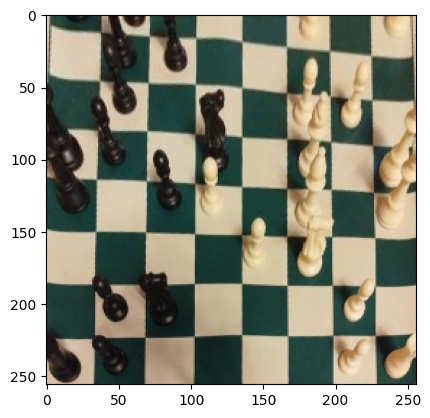

In [13]:
warpped_img, M = img.warp()
plt.imshow(warpped_img);
M